# The ROC-AUC Curve — From Scratch, Validated, and Applied

Companion notebook to the **interactive ROC-AUC figure** on the [Lecture 3 — Supervised Learning](../supervised-learning.html) page ([`roc-auc.html`](../roc-auc.html)).

The web figure lets you drag a classification threshold across two overlapping 1D score distributions and watch it trace out the ROC curve live, for a choice of "classifier quality" (how separated the two distributions are) and distribution shape (Gaussian, skewed, bimodal, uniform).

This notebook works through the same idea in three steps:

1. Build the exact distribution families and **from-scratch ROC/AUC computation** used by the web figure (plain numerical integration — no `sklearn` involved).
2. **Validate** that from-scratch computation against sampled data run through `sklearn.metrics.roc_curve` / `roc_auc_score`.
3. **Apply** it to a real trained classifier, so the toy 1D-distribution picture connects back to an actual model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

## 1. Score distributions for four "classifiers" and four distribution shapes

A classifier's raw output is a single number per example — the *score*. If we look at the score separately for the true-negative and true-positive examples, we get two overlapping 1D distributions. How much they overlap is exactly what the ROC curve visualizes.

Here, "classifier quality" is just a single **separation parameter `d`** that pushes the positive-class distribution away from the negative-class one. "Distribution shape" controls what family those two distributions belong to. Both are varied independently, exactly like the two dropdowns in the interactive figure.

In [2]:
def normal_pdf(x, mu, sigma):
    z = (x - mu) / sigma
    return np.exp(-0.5 * z**2) / (sigma * np.sqrt(2 * np.pi))


def lognormal_pdf(x, mu, sigma):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    mask = x > 0
    z = (np.log(x[mask]) - mu) / sigma
    out[mask] = np.exp(-0.5 * z**2) / (x[mask] * sigma * np.sqrt(2 * np.pi))
    return out


def uniform_pdf(x, a, b):
    x = np.asarray(x, dtype=float)
    return np.where((x >= a) & (x <= b), 1.0 / (b - a), 0.0)


def bimodal_pdf(x, mu_a, mu_b, sigma):
    return 0.5 * normal_pdf(x, mu_a, sigma) + 0.5 * normal_pdf(x, mu_b, sigma)


# Each shape returns (pdf_neg, pdf_pos) as a function of the separation `d`.
SHAPES = {
    "gaussian": dict(
        label="Gaussian (symmetric)", x_min=-9, x_max=9, n=900,
        dist=lambda d: (lambda x: normal_pdf(x, -d / 2, 1),
                         lambda x: normal_pdf(x, d / 2, 1)),
    ),
    "skewed": dict(
        label="Skewed (log-normal)", x_min=0.02, x_max=30, n=1400,
        dist=lambda d: (lambda x, s=d / 6: lognormal_pdf(x, 1.0 - s, 0.5),
                         lambda x, s=d / 6: lognormal_pdf(x, 1.0 + s, 0.5)),
    ),
    "bimodal": dict(
        label="Bimodal negative class", x_min=-11, x_max=11, n=1100,
        dist=lambda d: (lambda x: bimodal_pdf(x, -d / 2 - 1.8, -d / 2 + 1.8, 0.6),
                         lambda x: normal_pdf(x, d / 2, 1)),
    ),
    "uniform": dict(
        label="Uniform (boxcar)", x_min=-9, x_max=9, n=1000,
        dist=lambda d: (lambda x: uniform_pdf(x, -d / 2 - 2, -d / 2 + 2),
                         lambda x: uniform_pdf(x, d / 2 - 2, d / 2 + 2)),
    ),
}

# Each preset is just a separation value `d` — this is the "classifier quality" knob.
PRESETS = {
    "excellent": dict(label="Excellent classifier", d=5.0),
    "good":      dict(label="Good classifier", d=3.0),
    "fair":      dict(label="Fair classifier", d=1.5),
    "random":    dict(label="Random guess", d=0.0),
    "poor":      dict(label="Worse than random", d=-3.0),
}

## 2. Computing ROC/AUC from scratch (numerical integration)

Given the two densities, we don't need a closed-form CDF. We can:

1. Evaluate both densities on a fine grid.
2. Integrate them cumulatively (trapezoid rule) to get each class's CDF.
3. At every grid point `t` (a candidate threshold), the **survival function** `1 - CDF(t)` is the fraction of that class scoring above `t`.
   - `TPR(t) = P(score_pos > t)`
   - `FPR(t) = P(score_neg > t)`
4. Sweeping `t` across the whole grid traces the ROC curve; the AUC is the area under it (trapezoid rule again, this time over `(FPR, TPR)`).

This is exactly what the JavaScript in the interactive figure does — the code below is a line-for-line port.

In [3]:
def compute_roc(pdf_neg, pdf_pos, x_min, x_max, n=2000):
    xs = np.linspace(x_min, x_max, n)
    pn, pp = pdf_neg(xs), pdf_pos(xs)

    dx = xs[1] - xs[0]
    cdf_neg = np.concatenate(([0.0], np.cumsum(0.5 * (pn[1:] + pn[:-1]) * dx)))
    cdf_pos = np.concatenate(([0.0], np.cumsum(0.5 * (pp[1:] + pp[:-1]) * dx)))

    total_neg, total_pos = cdf_neg[-1], cdf_pos[-1]
    fpr = 1 - cdf_neg / total_neg
    tpr = 1 - cdf_pos / total_pos

    auc = np.sum(0.5 * (tpr[1:] + tpr[:-1]) * np.abs(fpr[:-1] - fpr[1:]))
    return dict(xs=xs, pdf_neg=pn, pdf_pos=pp, fpr=fpr, tpr=tpr, auc=auc)


# Sanity check: every shape's "random guess" preset should give AUC ≈ 0.500
for shape_key, shape in SHAPES.items():
    pdf_neg, pdf_pos = shape["dist"](PRESETS["random"]["d"])
    result = compute_roc(pdf_neg, pdf_pos, shape["x_min"], shape["x_max"], shape["n"])
    print(f"{shape_key:10s} random guess -> AUC = {result['auc']:.4f}")

gaussian   random guess -> AUC = 0.5000
skewed     random guess -> AUC = 0.5000
bimodal    random guess -> AUC = 0.5000
uniform    random guess -> AUC = 0.5000


## 3. Visualizing one example: distributions + threshold + ROC point

This reproduces one frozen frame of the interactive figure: the two score distributions with a threshold splitting each into a "predicted negative" / "predicted positive" region, and where that threshold lands on the ROC curve.

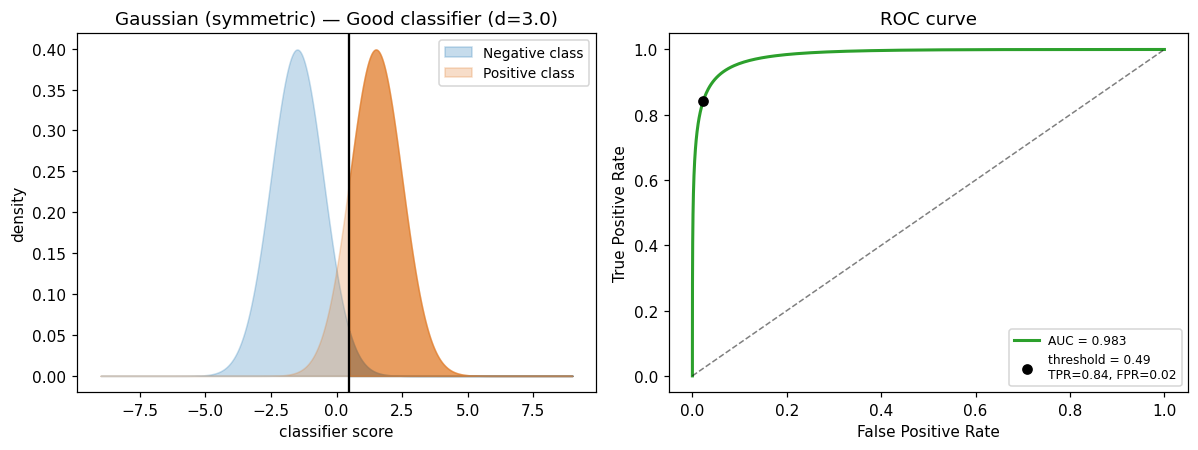

In [4]:
def plot_roc_frame(shape_key, preset_key, threshold):
    shape, preset = SHAPES[shape_key], PRESETS[preset_key]
    pdf_neg, pdf_pos = shape["dist"](preset["d"])
    result = compute_roc(pdf_neg, pdf_pos, shape["x_min"], shape["x_max"], shape["n"])

    idx = int(np.argmin(np.abs(result["xs"] - threshold)))
    fig, (ax_dist, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.2))

    xs = result["xs"]
    ax_dist.fill_between(xs, result["pdf_neg"], color="#1f77b4", alpha=0.25, label="Negative class")
    ax_dist.fill_between(xs, result["pdf_pos"], color="#e07b28", alpha=0.25, label="Positive class")
    ax_dist.fill_between(xs[idx:], result["pdf_neg"][idx:], color="#1f77b4", alpha=0.65)
    ax_dist.fill_between(xs[idx:], result["pdf_pos"][idx:], color="#e07b28", alpha=0.65)
    ax_dist.axvline(xs[idx], color="k", lw=1.5)
    ax_dist.set_title(f"{shape['label']} — {preset['label']} (d={preset['d']})")
    ax_dist.set_xlabel("classifier score")
    ax_dist.set_ylabel("density")
    ax_dist.legend(fontsize=9)

    ax_roc.plot(result["fpr"], result["tpr"], color="#2ca02c", lw=2, label=f"AUC = {result['auc']:.3f}")
    ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax_roc.scatter([result["fpr"][idx]], [result["tpr"][idx]], color="k", zorder=5,
                    label=f"threshold = {xs[idx]:.2f}\nTPR={result['tpr'][idx]:.2f}, FPR={result['fpr'][idx]:.2f}")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title("ROC curve")
    ax_roc.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    return fig, result


_ = plot_roc_frame("gaussian", "good", threshold=0.5)

## 4. How classifier quality changes the curve

Fixing the distribution shape and sweeping through the five classifier-quality presets shows the textbook relationship: more separation between the two score distributions bows the ROC curve further from the diagonal, and pushes AUC toward 1. A "random guess" classifier sits exactly on the diagonal (AUC = 0.5), and a classifier that's worse than random dips *below* it.

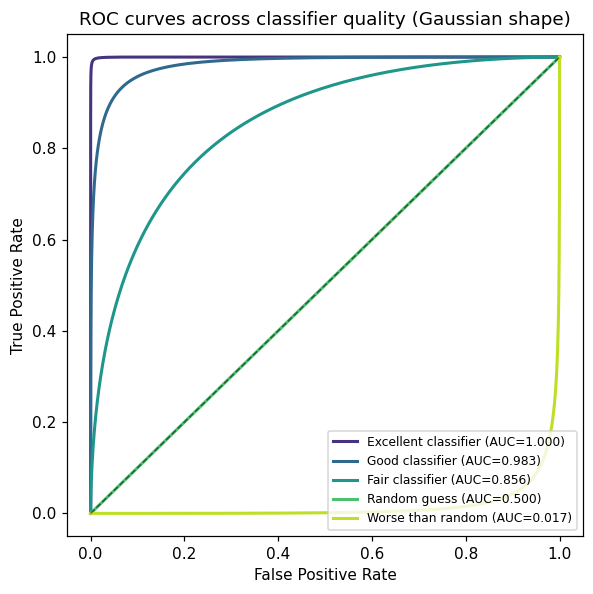

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(PRESETS)))

for color, (preset_key, preset) in zip(colors, PRESETS.items()):
    pdf_neg, pdf_pos = SHAPES["gaussian"]["dist"](preset["d"])
    result = compute_roc(pdf_neg, pdf_pos, SHAPES["gaussian"]["x_min"], SHAPES["gaussian"]["x_max"], SHAPES["gaussian"]["n"])
    ax.plot(result["fpr"], result["tpr"], color=color, lw=2,
            label=f"{preset['label']} (AUC={result['auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves across classifier quality (Gaussian shape)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

## 5. How distribution shape does — and doesn't — change AUC

Now fix the classifier-quality preset and vary the distribution shape instead. The separation parameter `d` isn't directly comparable across shapes — the same `d` value corresponds to different amounts of *actual overlapping probability mass* depending on the shape (a boxcar's edges separate cleanly once shifted past each other; a heavy-tailed log-normal keeps some overlap for much longer). That's why the four curves below, all nominally "Good classifier", land at noticeably different AUCs — a reminder that AUC is about how much probability mass overlaps, not about any specific parameter value.

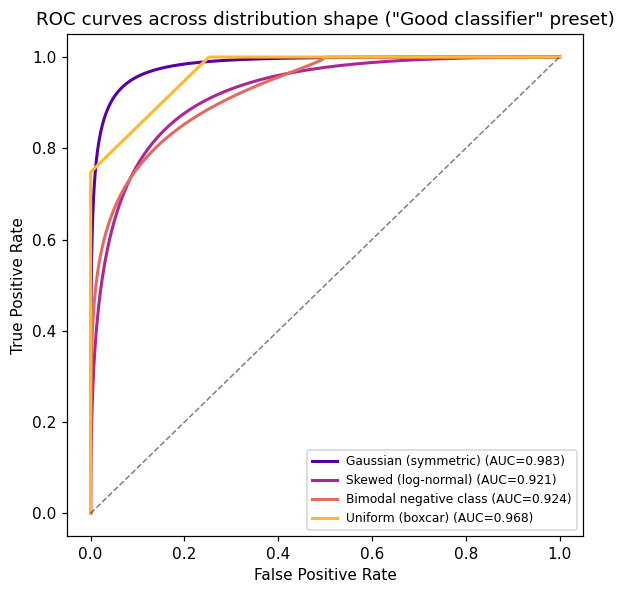

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(SHAPES)))

for color, (shape_key, shape) in zip(colors, SHAPES.items()):
    pdf_neg, pdf_pos = shape["dist"](PRESETS["good"]["d"])
    result = compute_roc(pdf_neg, pdf_pos, shape["x_min"], shape["x_max"], shape["n"])
    ax.plot(result["fpr"], result["tpr"], color=color, lw=2,
            label=f"{shape['label']} (AUC={result['auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves across distribution shape (\"Good classifier\" preset)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

## 6. Validating against sampled data and scikit-learn

Everything above is computed analytically from the densities via numerical integration — no actual data points involved. As a sanity check, let's **sample** real points from the same generative processes, hand them to `sklearn.metrics.roc_curve` / `roc_auc_score` the way you would with real model output, and compare the resulting AUC to the from-scratch analytic one.

In [7]:
def sample_shape(shape_key, preset_key, n_per_class=20_000, seed=0):
    """Draw samples from the exact generative process behind each shape/preset."""
    rng = np.random.default_rng(seed)
    d = PRESETS[preset_key]["d"]

    if shape_key == "gaussian":
        neg = rng.normal(-d / 2, 1, n_per_class)
        pos = rng.normal(d / 2, 1, n_per_class)
    elif shape_key == "skewed":
        s = d / 6
        neg = np.exp(rng.normal(1.0 - s, 0.5, n_per_class))
        pos = np.exp(rng.normal(1.0 + s, 0.5, n_per_class))
    elif shape_key == "bimodal":
        centers = rng.choice([-d / 2 - 1.8, -d / 2 + 1.8], size=n_per_class)
        neg = rng.normal(centers, 0.6)
        pos = rng.normal(d / 2, 1, n_per_class)
    elif shape_key == "uniform":
        neg = rng.uniform(-d / 2 - 2, -d / 2 + 2, n_per_class)
        pos = rng.uniform(d / 2 - 2, d / 2 + 2, n_per_class)
    else:
        raise ValueError(shape_key)
    return neg, pos


print(f"{'shape':10s} {'preset':10s}  {'analytic AUC':>13s}  {'sklearn AUC':>12s}  {'abs diff':>9s}")
for shape_key, shape in SHAPES.items():
    for preset_key, preset in PRESETS.items():
        pdf_neg, pdf_pos = shape["dist"](preset["d"])
        analytic = compute_roc(pdf_neg, pdf_pos, shape["x_min"], shape["x_max"], shape["n"])["auc"]

        neg, pos = sample_shape(shape_key, preset_key)
        y_true = np.concatenate([np.zeros_like(neg), np.ones_like(pos)])
        y_score = np.concatenate([neg, pos])
        sklearn_auc = roc_auc_score(y_true, y_score)

        print(f"{shape_key:10s} {preset_key:10s}  {analytic:13.4f}  {sklearn_auc:12.4f}  {abs(analytic - sklearn_auc):9.4f}")

shape      preset       analytic AUC   sklearn AUC   abs diff
gaussian   excellent          0.9998        0.9998     0.0000
gaussian   good               0.9830        0.9829     0.0001
gaussian   fair               0.8556        0.8544     0.0012
gaussian   random             0.5000        0.4985     0.0015
gaussian   poor               0.0170        0.0172     0.0003
skewed     excellent          0.9908        0.9907     0.0000
skewed     good               0.9213        0.9206     0.0008
skewed     fair               0.7602        0.7587     0.0015
skewed     random             0.5000        0.4985     0.0015
skewed     poor               0.0787        0.0783     0.0004
bimodal    excellent          0.9985        0.9985     0.0000
bimodal    good               0.9241        0.9231     0.0010
bimodal    fair               0.6981        0.6977     0.0004
bimodal    random             0.5000        0.4985     0.0015
bimodal    poor               0.0759        0.0750     0.0009
uniform 

The two columns agree to within ~0.001–0.003 across every shape/preset combination — the small residual is expected from finite sampling noise (20,000 points per class) and from truncating the numerical-integration grid to a finite range. This confirms the interactive figure's live AUC readout is computing the same quantity `sklearn.metrics.roc_auc_score` would on real predictions.

## 7. A real classifier: logistic regression on synthetic data

Finally, let's connect this back to an actual trained model rather than an idealized pair of densities. We generate a synthetic binary classification dataset (illustrative only — stand-in for e.g. a molecular descriptor matrix with an active/inactive screening label), fit a logistic regression, and look at its predicted-probability scores on held-out data exactly the way the interactive figure treats its two toy distributions.

Held-out AUC: 0.905


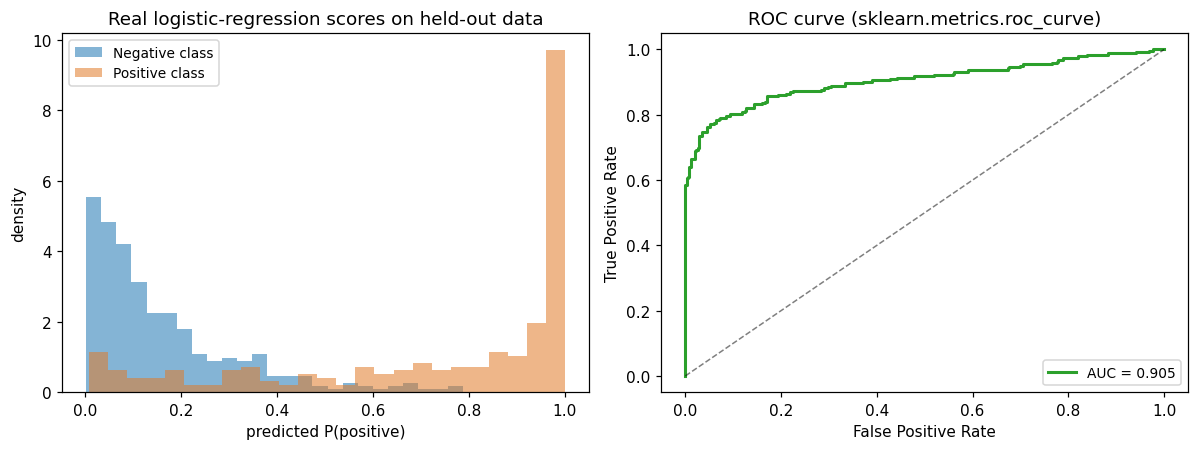

In [8]:
X, y = make_classification(
    n_samples=2000, n_features=12, n_informative=5, n_redundant=2,
    weights=[0.6, 0.4], class_sep=1.1, flip_y=0.03, random_state=0,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)

clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
scores_test = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, scores_test)
auc = roc_auc_score(y_test, scores_test)

fig, (ax_dist, ax_roc) = plt.subplots(1, 2, figsize=(11, 4.2))

ax_dist.hist(scores_test[y_test == 0], bins=25, alpha=0.55, density=True, color="#1f77b4", label="Negative class")
ax_dist.hist(scores_test[y_test == 1], bins=25, alpha=0.55, density=True, color="#e07b28", label="Positive class")
ax_dist.set_xlabel("predicted P(positive)")
ax_dist.set_ylabel("density")
ax_dist.set_title("Real logistic-regression scores on held-out data")
ax_dist.legend(fontsize=9)

ax_roc.plot(fpr, tpr, color="#2ca02c", lw=2, label=f"AUC = {auc:.3f}")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC curve (sklearn.metrics.roc_curve)")
ax_roc.legend(fontsize=9, loc="lower right")
fig.tight_layout()

print(f"Held-out AUC: {auc:.3f}")

## Summary

- The ROC curve is what you get by sweeping a decision threshold across a classifier's score and plotting TPR against FPR at every value.
- AUC is threshold-independent by construction — it equals the probability that a randomly drawn positive example scores higher than a randomly drawn negative one.
- **AUC = 0.5** means the two score distributions completely coincide — no threshold does better than a coin flip.
- **AUC < 0.5** doesn't mean the score is useless — it means it's anti-correlated with the label. Flipping the decision rule (or negating the score) gives a classifier with `AUC' = 1 - AUC`.
- The *shape* of the score distributions barely matters to how you should think about the curve — only how much probability mass overlaps between the two classes does.
- Everything here — the from-scratch numerical integration, the sampled-data cross-check against `sklearn`, and the real logistic-regression example — computes the exact same AUC definition the interactive figure's live badge shows as you drag the threshold.